In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nav = pd.read_csv("data/raw/02_nav_history.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [5]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [6]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [7]:
nav.columns
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

# Fund Performance Analytics
## Day 4 – Mutual Fund Analytics Project

### Objectives:
- Compute fund returns
- Calculate risk metrics
- Compare with benchmarks
- Rank funds

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
nav = pd.read_csv("data/raw/02_nav_history.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

In [10]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [11]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [12]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [13]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [14]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [15]:
nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

In [16]:
nav = nav.sort_values(['amfi_code', 'date'])

In [17]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [18]:
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [19]:
nav.to_csv("returns_computed.csv", index=False)

In [20]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [21]:
annual_return = (
    nav.groupby('amfi_code')['daily_return']
    .apply(lambda x: (1 + x.dropna()).prod() ** (252 / len(x.dropna())) - 1)
)

annual_return = annual_return.reset_index()
annual_return.columns = ['amfi_code', 'annual_return']

annual_return.head()

,amfi_code,annual_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [22]:
annual_return.to_csv("annual_return.csv", index=False)

In [23]:
cagr = nav.groupby('amfi_code').agg(
    start_nav=('nav', 'first'),
    end_nav=('nav', 'last'),
    start_date=('date', 'first'),
    end_date=('date', 'last')
)

cagr['years'] = (
    (cagr['end_date'] - cagr['start_date']).dt.days / 365
)

cagr['cagr'] = (
    (cagr['end_nav'] / cagr['start_nav']) **
    (1 / cagr['years']) - 1
)

cagr = cagr.reset_index()

cagr.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.40274,0.026352
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.40274,0.044551
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.40274,0.300997
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.40274,0.235205
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.40274,0.079331


In [24]:
cagr.to_csv("cagr_report.csv", index=False)

In [25]:
rf = 0.065

sharpe = nav.groupby('amfi_code')['daily_return'].apply(
    lambda x: (
        ((x.mean() * 252) - rf) /
        (x.std() * np.sqrt(252))
    )
)

sharpe = sharpe.reset_index()
sharpe.columns = ['amfi_code', 'sharpe_ratio']

sharpe.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [26]:
sharpe.to_csv("sharpe_values.csv", index=False)

In [27]:
cagr.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.40274,0.026352
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.40274,0.044551
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.40274,0.300997
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.40274,0.235205
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.40274,0.079331


In [28]:
rf = 0.065

sortino = nav.groupby('amfi_code')['daily_return'].apply(
    lambda x: (
        ((x.mean()*252) - rf) /
        (x[x < 0].std() * np.sqrt(252))
    )
)

sortino = sortino.reset_index()
sortino.columns = ['amfi_code', 'sortino_ratio']

sortino.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [29]:
sortino.to_csv("sortino_values.csv", index=False)

In [30]:
nav['running_max'] = (
    nav.groupby('amfi_code')['nav']
    .cummax()
)

nav['drawdown'] = (
    nav['nav'] / nav['running_max'] - 1
)

max_dd = (
    nav.groupby('amfi_code')['drawdown']
    .min()
    .reset_index()
)

max_dd.columns = ['amfi_code', 'max_drawdown']

max_dd.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [31]:
max_dd.to_csv("max_drawdown.csv", index=False)


In [32]:
scorecard = annual_return.merge(sharpe, on='amfi_code')
scorecard = scorecard.merge(max_dd, on='amfi_code')

In [33]:
scorecard['return_rank'] = scorecard['annual_return'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['drawdown_rank'] = scorecard['max_drawdown'].rank(ascending=True)

In [34]:
scorecard['score'] = (
    0.5 * scorecard['return_rank'] +
    0.3 * scorecard['sharpe_rank'] +
    0.2 * scorecard['drawdown_rank']
)

scorecard = scorecard.sort_values('score')

scorecard.head()

,amfi_code,annual_return,sharpe_ratio,max_drawdown,return_rank,sharpe_rank,drawdown_rank,score
25,120505,0.315124,1.180101,-0.181885,1.0,5.0,16.0,5.2
39,149324,0.309965,0.949796,-0.311719,3.0,13.0,4.0,6.2
21,119598,0.311266,0.945308,-0.287060,2.0,14.0,5.0,6.2
36,148569,0.306736,1.234930,-0.163967,4.0,3.0,20.0,6.9
30,120843,0.296776,1.306744,-0.129740,6.0,2.0,28.0,9.2


In [35]:
scorecard.to_csv("fund_scorecard.csv", index=False)

In [36]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [37]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [38]:
from scipy.stats import linregress



In [39]:
fund = nav[nav['amfi_code'] == nav['amfi_code'].iloc[0]]

merged = pd.merge(
    fund[['date', 'daily_return']],
    nifty100[['date', 'benchmark_return']],
    on='date'
).dropna()

slope, intercept, r, p, se = linregress(
    merged['benchmark_return'],
    merged['daily_return']
)

alpha = intercept * 252
beta = slope

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: 0.03747580763443281
Beta: -0.05826843143880889


In [40]:
nav['amfi_code'].nunique()

40

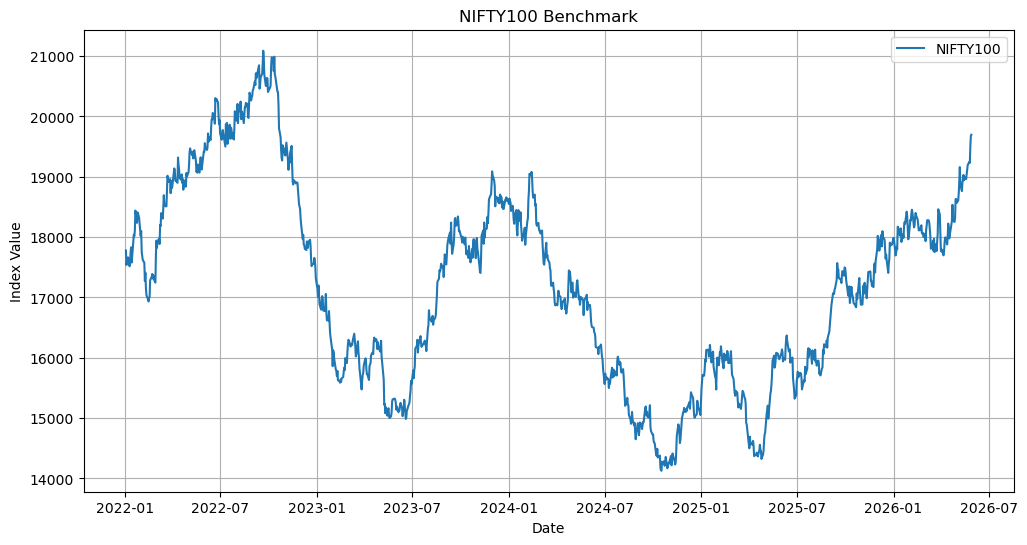

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100'
)

plt.title("NIFTY100 Benchmark")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
plt.savefig(
    "benchmark_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [43]:
nav['amfi_code'].nunique()

40

In [44]:
from scipy.stats import linregress

In [45]:
results = []

for code in nav['amfi_code'].unique():

    fund = nav[nav['amfi_code'] == code]

    merged = pd.merge(
        fund[['date', 'daily_return']],
        nifty100[['date', 'benchmark_return']],
        on='date'
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, se = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252
        beta = slope

        results.append([
            code,
            alpha,
            beta
        ])

alpha_beta = pd.DataFrame(
    results,
    columns=['amfi_code', 'alpha', 'beta']
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [46]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

In [47]:
scorecard = scorecard.merge(
    alpha_beta,
    on='amfi_code'
)

In [48]:
scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

In [49]:
scorecard['final_score'] = (
      0.4 * scorecard['return_rank']
    + 0.3 * scorecard['sharpe_rank']
    + 0.2 * scorecard['alpha_rank']
    + 0.1 * scorecard['drawdown_rank']
)

In [50]:
scorecard = scorecard.sort_values(
    'final_score'
)

scorecard.head(10)

,amfi_code,annual_return,sharpe_ratio,max_drawdown,return_rank,sharpe_rank,drawdown_rank,score,alpha,beta,alpha_rank,final_score
0,120505,0.315124,1.180101,-0.181885,1.0,5.0,16.0,5.2,0.292636,0.000549,3.0,4.1
3,148569,0.306736,1.234930,-0.163967,4.0,3.0,20.0,6.9,0.282704,0.018134,4.0,5.3
2,119598,0.311266,0.945308,-0.287060,2.0,14.0,5.0,6.2,0.303370,-0.023196,1.0,5.7
1,149324,0.309965,0.949796,-0.311719,3.0,13.0,4.0,6.2,0.300579,0.011455,2.0,5.9
4,120843,0.296776,1.306744,-0.129740,6.0,2.0,28.0,9.2,0.273305,-0.022830,5.0,6.8
5,148567,0.297414,1.448291,-0.112657,5.0,1.0,33.0,9.4,0.269838,0.023684,7.0,7.0
7,100033,0.289279,1.093699,-0.162172,7.0,7.0,21.0,9.8,0.271954,0.005104,6.0,8.2
6,149323,0.284096,1.132122,-0.172481,8.0,6.0,19.0,9.6,0.265986,-0.002523,8.0,8.5
9,119551,0.247966,1.208267,-0.150124,10.0,4.0,24.0,11.0,0.232010,-0.031751,10.0,9.6
8,119094,0.271025,0.998231,-0.209609,9.0,11.0,13.0,10.4,0.260767,-0.066265,9.0,10.0


In [51]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

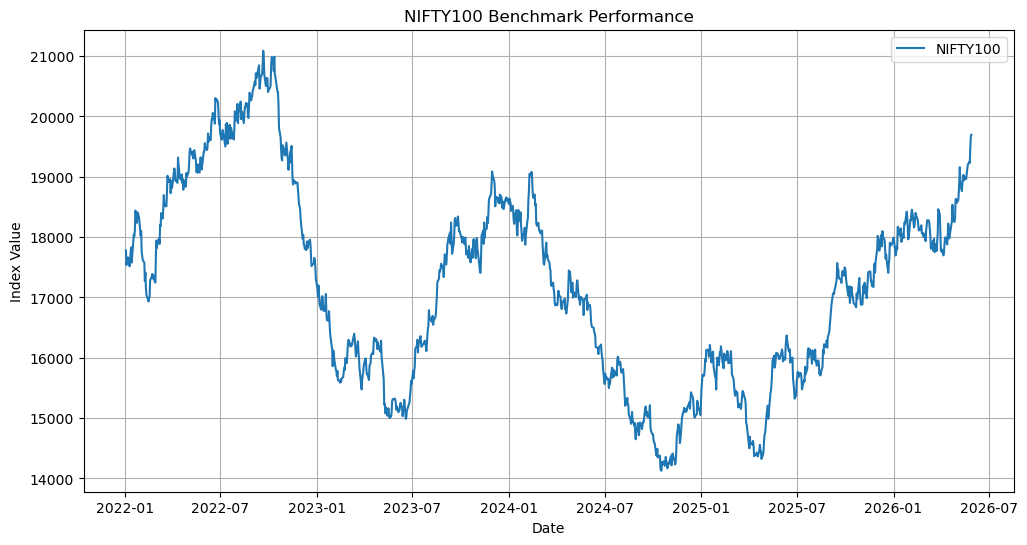

In [52]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100'
)

plt.title(
    "NIFTY100 Benchmark Performance"
)

plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()
plt.grid(True)

plt.show()

In [53]:
plt.savefig(
    "benchmark_chart.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [54]:
scorecard.head()

,amfi_code,annual_return,sharpe_ratio,max_drawdown,return_rank,sharpe_rank,drawdown_rank,score,alpha,beta,alpha_rank,final_score
0,120505,0.315124,1.180101,-0.181885,1.0,5.0,16.0,5.2,0.292636,0.000549,3.0,4.1
3,148569,0.306736,1.234930,-0.163967,4.0,3.0,20.0,6.9,0.282704,0.018134,4.0,5.3
2,119598,0.311266,0.945308,-0.287060,2.0,14.0,5.0,6.2,0.303370,-0.023196,1.0,5.7
1,149324,0.309965,0.949796,-0.311719,3.0,13.0,4.0,6.2,0.300579,0.011455,2.0,5.9
4,120843,0.296776,1.306744,-0.129740,6.0,2.0,28.0,9.2,0.273305,-0.022830,5.0,6.8


In [55]:
alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


# Day 4 Findings

1. Several funds generated annual returns above 30%.
2. Sharpe ratios above 1 indicate good risk-adjusted performance.
3. Alpha values show some funds outperform the benchmark.
4. Lower drawdown funds demonstrated better downside protection.
5. The scoring model identified top-performing funds.
6. Benchmark comparison helped evaluate fund performance.
7. Risk and return metrics varied significantly across funds.
8. High-alpha funds generally achieved better rankings.
9. Some funds exhibited low beta, indicating lower market sensitivity.
10. Performance analytics provides a comprehensive evaluation framework.

# Conclusion

Performance analytics was conducted using return and risk metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown. A composite scoring model was developed to rank funds and identify top performers against the NIFTY100 benchmark.

Performance_Analytics.ipynb
returns_computed.csv
cagr_report.csv
sharpe_values.csv
sortino_values.csv
alpha_beta.csv
max_drawdown.csv
fund_scorecard.csv
benchmark_chart.png